In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import matplotlib.pyplot as plt
import glob
import os

import gc
import numpy as np
import numpy.lib.recfunctions as rfn
import fitsio

In [ ]:
rootdir = "/gpfs02/work/xiangchong.li/work/hsc_data/s23b/"

field_list = ["hectomap", "spring1", "spring2", "spring3", "autumn1", "autumn2"]
full = fitsio.read(
    f"{rootdir}/tracts_fdfc_v1_final.fits"
)

for field in field_list:
    print(field)
    mm = full["field"] == field
    selected = full[mm]
    tlist = np.unique(selected["tract"])
    area = 0.0
    for tt in tlist:
        fname = os.path.join(rootdir, f"db_random/random_masked_{tt}.fits")
        area += (len(fitsio.read(fname)) / 100 / 3600.0)
    print(area)

In [2]:
46.32 + 134.85 + 144.38 + 145.38 + 155.54 + 160

786.4699999999999

In [3]:
cat_dir = "/gpfs02/work/xiangchong.li/work/hsc_data/catalog_v2/s23b_shape"
colnames = ["e1", "e2", "wsel", 'e22c', 'e22s', 'e44c', 'e44s']

field_list = ["hectomap", "spring1", "spring2", "spring3", "autumn1", "autumn2"]

sel = []
for field in field_list:
    sel.append(
        fitsio.read(
            "/gpfs02/work/xiangchong.li/work/hsc_data/catalog_v2/s23b_selection/bin_%s_noshear_updated.fits" %field
        )
    )
sel = rfn.stack_arrays(sel, usemask=False, asrecarray=False, autoconvert=True)
mask =sel["bin_fiducial"]>=0
gc.collect()

7

In [4]:
cat_dir = "/gpfs02/work/xiangchong.li/work/hsc_data/catalog_v2/s23b_shape"
colnames = ["e1", "e2", "wsel", 'e22c', 'e22s', 'e44c', 'e44s']

field_list = ["hectomap", "spring1", "spring2", "spring3", "autumn1", "autumn2"]
data = []
res = []
for field in field_list:
    data.append(
        fitsio.read(
            os.path.join(cat_dir, "anacal_%s.fits" % field),
            columns=colnames,
        )
    )
    res.append(
        fitsio.read(
            os.path.join(cat_dir, ".response", "%s.fits" % field),
            columns=["response"],
        )
    )
gc.collect()    

0

In [5]:
data = rfn.stack_arrays(data, usemask=False, asrecarray=False, autoconvert=True)
res = rfn.stack_arrays(res, usemask=False, asrecarray=False, autoconvert=True)
data = data[mask]
res = res[mask]
gc.collect()

3

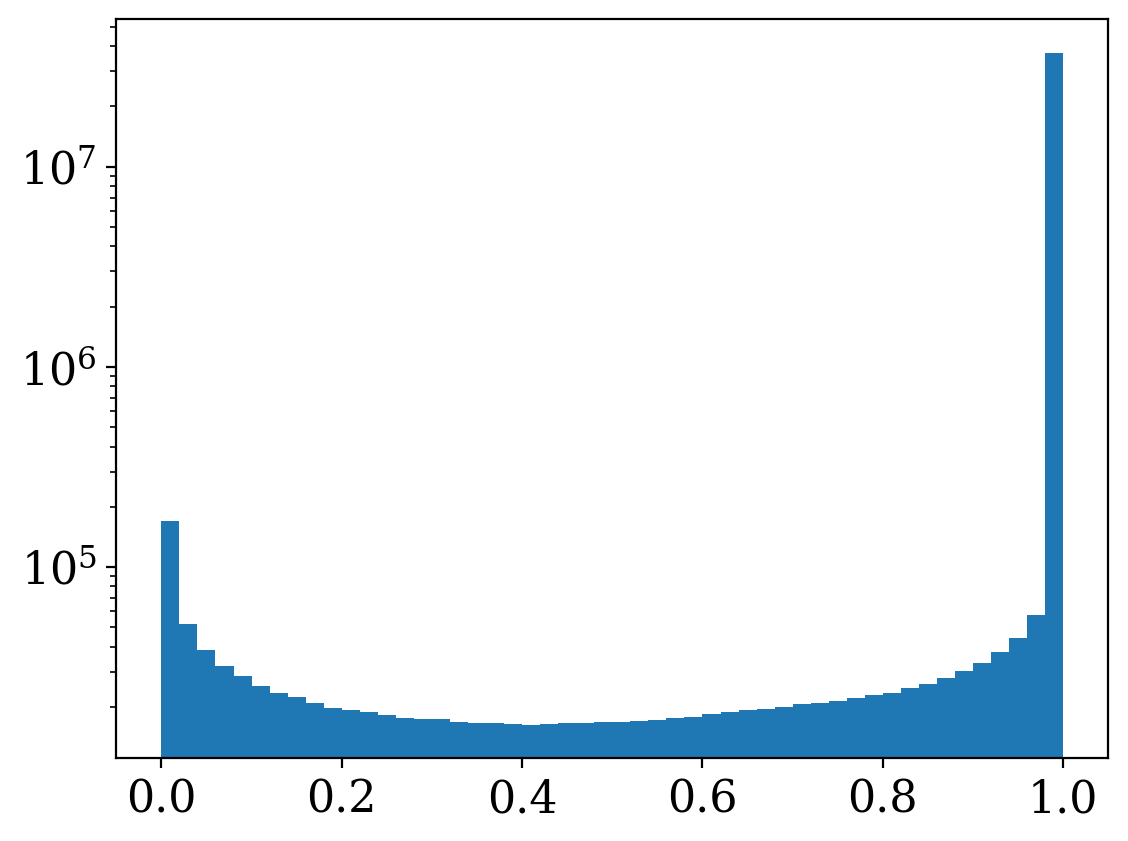

In [23]:
plt.hist(data["wsel"], bins=50)
plt.yscale("log")

In [28]:
print(np.sum(data["wsel"]) / len(data))

0.9815972309152933


In [26]:
len(data)

38385230

In [6]:
print(len(mask) / 800 / 3600)

34.971884027777776


In [20]:
# Selection and detection responses for bin 1,2,3,4
sel_responses = [-0.05688,-0.04984,-0.05437,-0.05823]
det_responses = [-0.01066,-0.01117,-0.00989,-0.01477]
g1, g2 = get_shear(catalog=data, response=res, sel_response=-0.00, det_response =-0.00)

0.33720042972826714


In [15]:
print(np.std(g1))
print(np.std(g2))

0.2757027474781139
0.2776484478715587


In [16]:
len(g1) / 800 / 3600

13.32820486111111

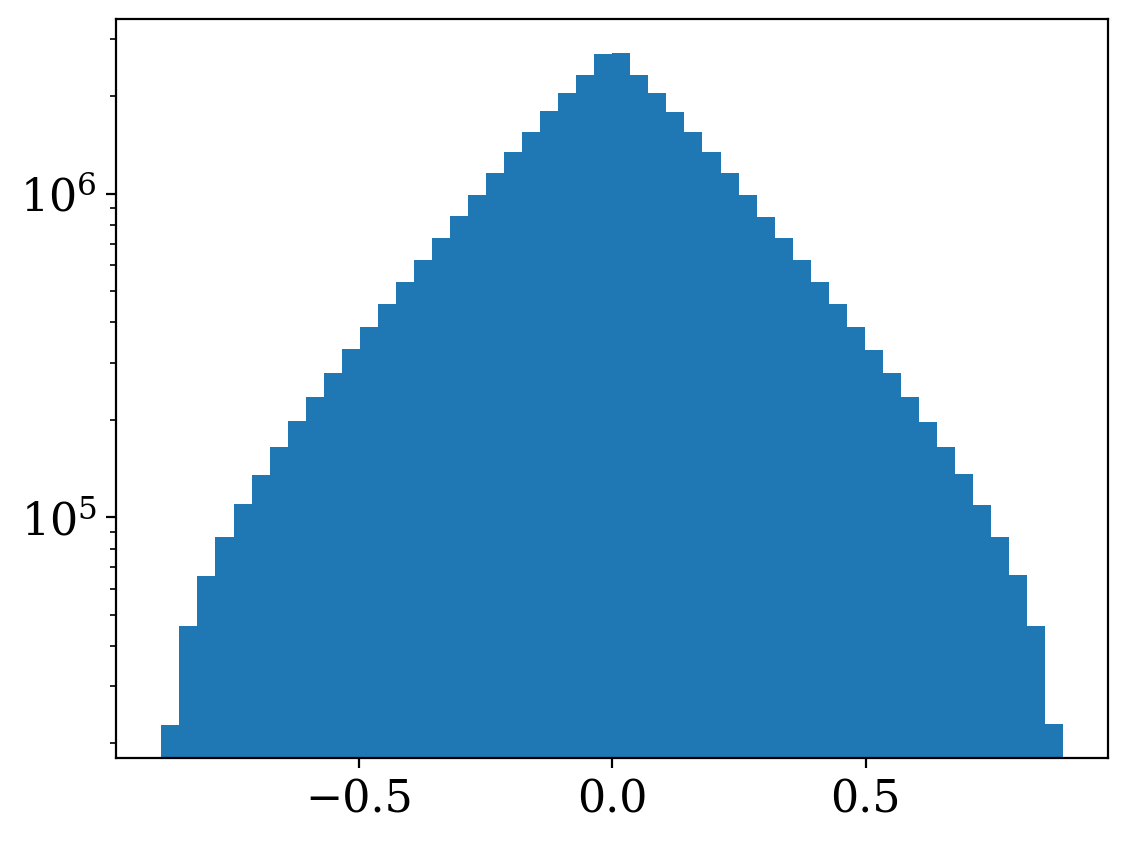

In [17]:
plt.hist(g1,bins=50)
plt.yscale("log")

In [19]:
def _rotate(*, c, s, phi_rad):
    # Do rotation
    cp = np.cos(phi_rad)
    sp = np.sin(phi_rad)
    return c * cp - s * sp, c * sp + s * cp

def get_response_average(*, catalog, response, dm1_plus1=1.0, sel_response=0.0, det_response=0.0):
    response_average = np.average(catalog["wsel"] * (
        response["response"] * dm1_plus1
        + np.sqrt(2.0) / 2.0 * (
            catalog["e22c"] * catalog["e1"]
            + catalog["e22s"] * catalog["e2"]
        )
    )) + sel_response + det_response
    return response_average

def get_shear(
    *,
    catalog, response,
    sim=None, dm1_plus1=1.0, 
    do_rotation=True, 
    sel_response=0.0, det_response=0.0,
):
    """
    Compute per-object shear estimators (g1, g2) from measured spin moments and
    a (scalar) shear response, optionally applying a known rotation and
    optionally including first-order simulated shear terms.
    Parameters
    ----------
    catalog : mapping or numpy structured array
        Per-object measurements. Must provide fields/keys:
        - "wsel" : weight for selection and detection
        - "e1", "e2" : spin-2 ellipticity-like components
        - "e22c", "e22s" : spin-2 components used in the response correction
        - "e44c", "e44s" : spin-4 components used in the response correction
    response : mapping
        Response information. Must provide:
        - "response" : base (scalar or per-object) shear response term.
    sim : mapping or None, optional
        If provided, enables two behaviors:
        - rotation: uses `sim["rot_angle"]` (radians) when `do_rotation=True`
        - injected shear correction: uses `sim["g1_sim"]` and `sim["g2_sim"]`
          to include first-order terms in the numerator.
        If None, the estimator is computed without injected-shear corrections.
    dm1_plus1 : float, optional
        Multiplicative blinding factor applied to `response["response"]`.
        Use 1.0 for no extra scaling.
    do_rotation : bool, optional
        If True and `sim` is not None, rotate all spin components by
        `rot_angle` (spin-2 uses 2*rot_angle; spin-4 uses 4*rot_angle).
        If False (or `sim` is None), no rotation is applied.
    sel_response : float, optional
        Additional selection response contribution. In the current
        implementation it is added to the response denominator and, when `sim`
        is provided, contributes to the numerator as `g*_sim * sel_response`.
    det_response : float, optional
        Additional selection response contribution. In the current
        implementation it is added to the response denominator and, when `sim`
        is provided, contributes to the numerator as `g*_sim * det_response`.
    Returns
    -------
    g1 : numpy.ndarray
        Per-object shear estimator for the first component.
    g2 : numpy.ndarray
        Per-object shear estimator for the second component.
    """
    if do_rotation and (sim is not None):
        rot_angle = sim["rot_angle"]
    else:
        rot_angle = 0.0
    # rotation
    e1, e2 = _rotate(c=catalog["e1"], s=catalog["e2"], phi_rad=2.0*rot_angle)
    e22c, e22s = _rotate(
        c=catalog["e22c"], s=catalog["e22s"], phi_rad=2.0*rot_angle,
    )
    e44c, e44s = _rotate(
        c=catalog["e44c"], s=catalog["e44s"], phi_rad=4.0*rot_angle,
    )
    # shear
    de1_dg1 = (
        response["response"] * dm1_plus1
        - np.sqrt(3.0) * e44c + np.sqrt(2.0) * e22c * e1
    )
    de2_dg2 = (
        response["response"] * dm1_plus1
        + np.sqrt(3.0) * e44c + np.sqrt(2.0) * e22s * e2
    )
    de1_dg2 = -np.sqrt(3.0) * e44s + np.sqrt(2.0) * e22s * e1
    de2_dg1 = -np.sqrt(3.0) * e44s + np.sqrt(2.0) * e22c * e2
    # include detection and selection response
    if sim is None:
        we1 = catalog["wsel"] * e1
        we2 = catalog["wsel"] * e2
    else:
        we1 = catalog["wsel"] * (
            e1 + de1_dg1 * sim["g1_sim"]
            + de1_dg2 * sim["g2_sim"]
        ) + sim["g1_sim"] * (sel_response + det_response)
        we2 = catalog["wsel"] * (
            e2 + de2_dg1 * sim["g1_sim"]
            + de2_dg2 * sim["g2_sim"]
        ) + sim["g2_sim"] * (sel_response + det_response)
    response_average = get_response_average(
        catalog=catalog, response=response,
        dm1_plus1=dm1_plus1, sel_response=sel_response, 
        det_response=det_response,
    )
    print(response_average)
    g1 = we1 / response_average
    g2 = we2 / response_average
    return g1, g2